In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

#path to data folder
data_path = "../data"

# emotion mapping based on instructions
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': ' fearful',
    '07': 'disgust',
    '08': 'surprised'
}

intensity_map = {
    '01': 'normal',
    '02': 'strong'
}

vocal_channel_map = {
    '01': 'speech',
    '02': 'song'
}

# loop through all of the .wav files and parse the filenames
records = []
# go into the big actor files
for zip_folder in sorted(os.listdir(data_path)):
    zip_path=os.path.join(data_path, zip_folder)
    if not os.path.isdir(zip_path):
        continue
        # go into individual actor files
    for actor_folder in sorted(os.listdir(zip_path)):
        actor_path = os.path.join(zip_path, actor_folder)
        if not os.path.isdir(actor_path):
            continue
            #get wav files from actor files
        for filename in sorted(os.listdir(actor_path)):
            if not filename.endswith('.wav'):
                continue
                # spliting the file name into individual numbers so we can append to the list easily
            parts = filename.replace('.wav', '').split('-')
            # adds to the record array
            records.append({
                'filename': filename,
                'filepath': os.path.join(actor_path, filename),
                'vocal_channel': vocal_channel_map[parts[1]],
                'emotion': emotion_map[parts[2]],
                'intensity': intensity_map[parts[3]],
                'statement': parts[4],
                'repetition':parts[5],
                'actor': int(parts[6]),
                'gender': 'male' if int(parts[6]) % 2 != 0 else 'female'
            })

df = pd.DataFrame(records)
print(df.shape)
df.head()



(2452, 9)


,filename,filepath,vocal_channel,emotion,intensity,statement,repetition,actor,gender
0,03-02-01-01-01-01-01.wav,../data\Audio_Song_Actors_01-24\Actor_01\03-02...,song,neutral,normal,01,01,1,male
1,03-02-01-01-01-02-01.wav,../data\Audio_Song_Actors_01-24\Actor_01\03-02...,song,neutral,normal,01,02,1,male
2,03-02-01-01-02-01-01.wav,../data\Audio_Song_Actors_01-24\Actor_01\03-02...,song,neutral,normal,02,01,1,male
3,03-02-01-01-02-02-01.wav,../data\Audio_Song_Actors_01-24\Actor_01\03-02...,song,neutral,normal,02,02,1,male
4,03-02-02-01-01-01-01.wav,../data\Audio_Song_Actors_01-24\Actor_01\03-02...,song,calm,normal,01,01,1,male


In [2]:
def extract_features(filepath):
    try: 
        # loading files where y is an array  of the raw audio signal, and sr is the sample rate. 48000 to match our file format of RAVDESS
        y, sr = librosa.load(filepath, sr=48000)
        features = {}

        # Mel-frequency cepstral coefficients, we are using 13
        # each file has a different length, so we get teh mean dn standard deviation and convert the matrix into a fixed set of 26 numbers 13 means and 13 stds to go into the data frame
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            features[f'mfcc_{i+1}_mean'] = np.mean(mfcc[i])
            features[f'mfcc_{i+1}_std'] = np.std(mfcc[i])
        # calculating how much the MFCC coeffeienct changed from frame to frame, again summarized into 26 numbers 
        mfcc_delta = librosa.feature.delta(mfcc)
        for i in range(13):
            features[f'mfcc_delta_{i+1}_mean'] = np.mean(mfcc_delta[i])
            features[f'mfcc_delta_{i+1}_std'] = np.std(mfcc_delta[i])
        # how much the deltas are changing each frame
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        for i in range(13):
            features[f"mfcc_delta2_{i+1}_mean"] = np.mean(mfcc_delta2[i])
            features[f"mfcc_delta2_{i+1}_std"] = np.std(mfcc_delta2[i])
        
        #captures every time the audio signal goes from positive to negative, high ZCR indicates noisier/ more exciting emotions
        zcr = librosa.feature.zero_crossing_rate(y)
        features['zcr_mean'] = np.mean(zcr)
        features['zcr_std'] = np.std(zcr)
        # captures the loudness of the file per frame, louder = higher
        rms = librosa.feature.rms(y=y)
        features['rms_mean'] = np.mean(rms)
        features['rms_std'] = np.std(rms)
        # center of mass, basically how sharp the sound is, higher sound means higher frequency
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        features['spectral_centroid_mean'] = np.mean(centroid)
        features['spectral_centroid_std'] = np.std(centroid)
        # how spread out the frequencies are around the centroid, narrow = concentrated at certain frequencies, wide = spread across many frequencies
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        features['spectral_bandwidth_mean'] = np.mean(bandwidth)
        features['spectral_bandwidth_std'] = np.std(bandwidth)
        # what frequency has 85% of the total energy in the file, lower number = the energy is concentrated in the lower frequencies, higher = energy is located in the higher frequiencies.
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        features['spectral_rolloff_mean'] = np.mean(rolloff)
        features["spectral_rolloff_std"] = np.std(rolloff)
        # represents pith classes and how much energy is in class
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        for i in range(12):
            features[f'chroma_{i+1}_mean'] = np.mean(chroma[i])
            features[f'chroma_{i+1}_std'] = np.std(chroma[i])

        return features


    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        return None


In [3]:
# extract features for every file
feature_list = []

for idx,row in df.iterrows():
    print(f"Processing file {idx+1}/{len(df)}: {row['filename']}", end = '\r')

    features = extract_features(row['filepath'])
    
    if features is not None:
        #adding meta data colmuns
        features['filename'] = row['filename']
        features['emotion'] = row['emotion']
        features['vocal_channel'] = row['vocal_channel']
        features['intensity'] = row['intensity']
        features['actor'] = row['actor']
        features['gender'] = row['gender']

        feature_list.append(features)

features_df = pd.DataFrame(feature_list)
print(f'Extracted freatures for {len(features_df)} files')
print(features_df.shape)

c:\Users\alex\OneDrive\Documents\GitHub\Project_CSE432-532\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracted freatures for 2452 files8-02-02-02-24.wav
(2452, 118)


In [4]:

csv_path = '../data/features.csv'
if not os.path.exists(csv_path):
    features_df.to_csv('../data/features.csv', index=False)
    print("features saved to features.csv")
else:
    print('features.csv already exist')

features_df = pd.read_csv('../data/features.csv')
print(features_df.shape)
features_df.head()

features.csv already exist
(2452, 118)


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,chroma_11_mean,chroma_11_std,chroma_12_mean,chroma_12_std,filename,emotion,vocal_channel,intensity,actor,gender
0,-625.10626,171.06696,86.008800,82.467290,-14.908679,27.146862,11.612943,22.529451,0.951541,13.949370,...,0.341462,0.345285,0.453775,0.370987,03-02-01-01-01-01-01.wav,neutral,song,normal,1,male
1,-599.41614,169.72461,84.052720,80.548706,-15.714042,27.120998,11.429275,22.343155,0.850099,13.008116,...,0.348859,0.358894,0.467595,0.371645,03-02-01-01-01-02-01.wav,neutral,song,normal,1,male
2,-612.90310,166.08420,82.196556,84.176260,-13.120657,28.893564,14.789132,26.891737,3.518428,12.495246,...,0.382692,0.360967,0.450121,0.348187,03-02-01-01-02-01-01.wav,neutral,song,normal,1,male
3,-610.18787,176.57068,83.249810,82.042950,-15.969199,27.200315,13.755888,24.902111,1.984430,10.410358,...,0.382666,0.348640,0.499852,0.357780,03-02-01-01-02-02-01.wav,neutral,song,normal,1,male
4,-623.87710,165.66798,90.996020,79.395660,-11.470400,24.785646,15.081040,22.237210,2.816189,13.893244,...,0.438312,0.331005,0.486837,0.301706,03-02-02-01-01-01-01.wav,calm,song,normal,1,male


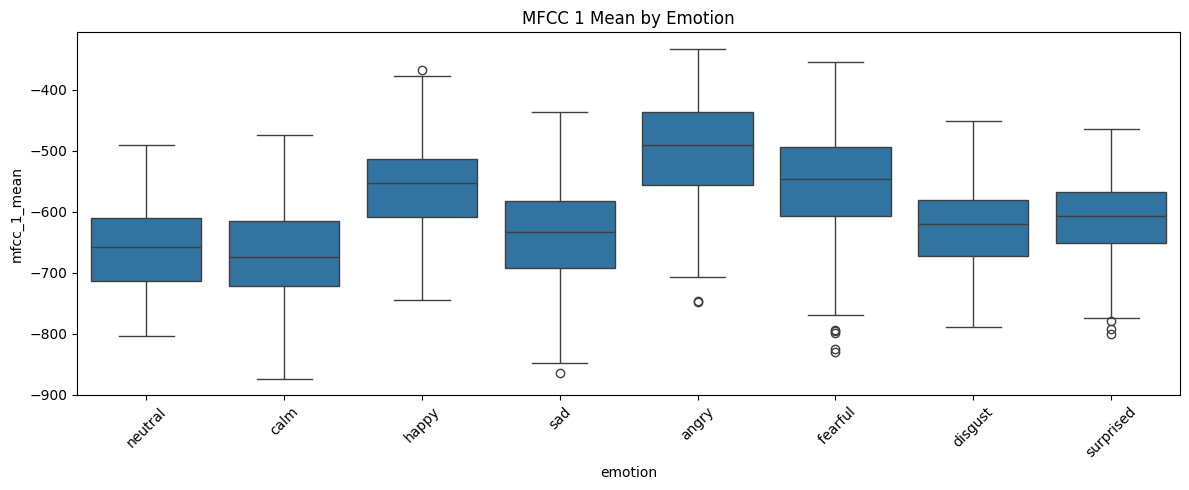

In [6]:
plt.figure(figsize=(12,5))
sns.boxplot(data=features_df, x='emotion', y='mfcc_1_mean')
plt.title('MFCC 1 Mean by Emotion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

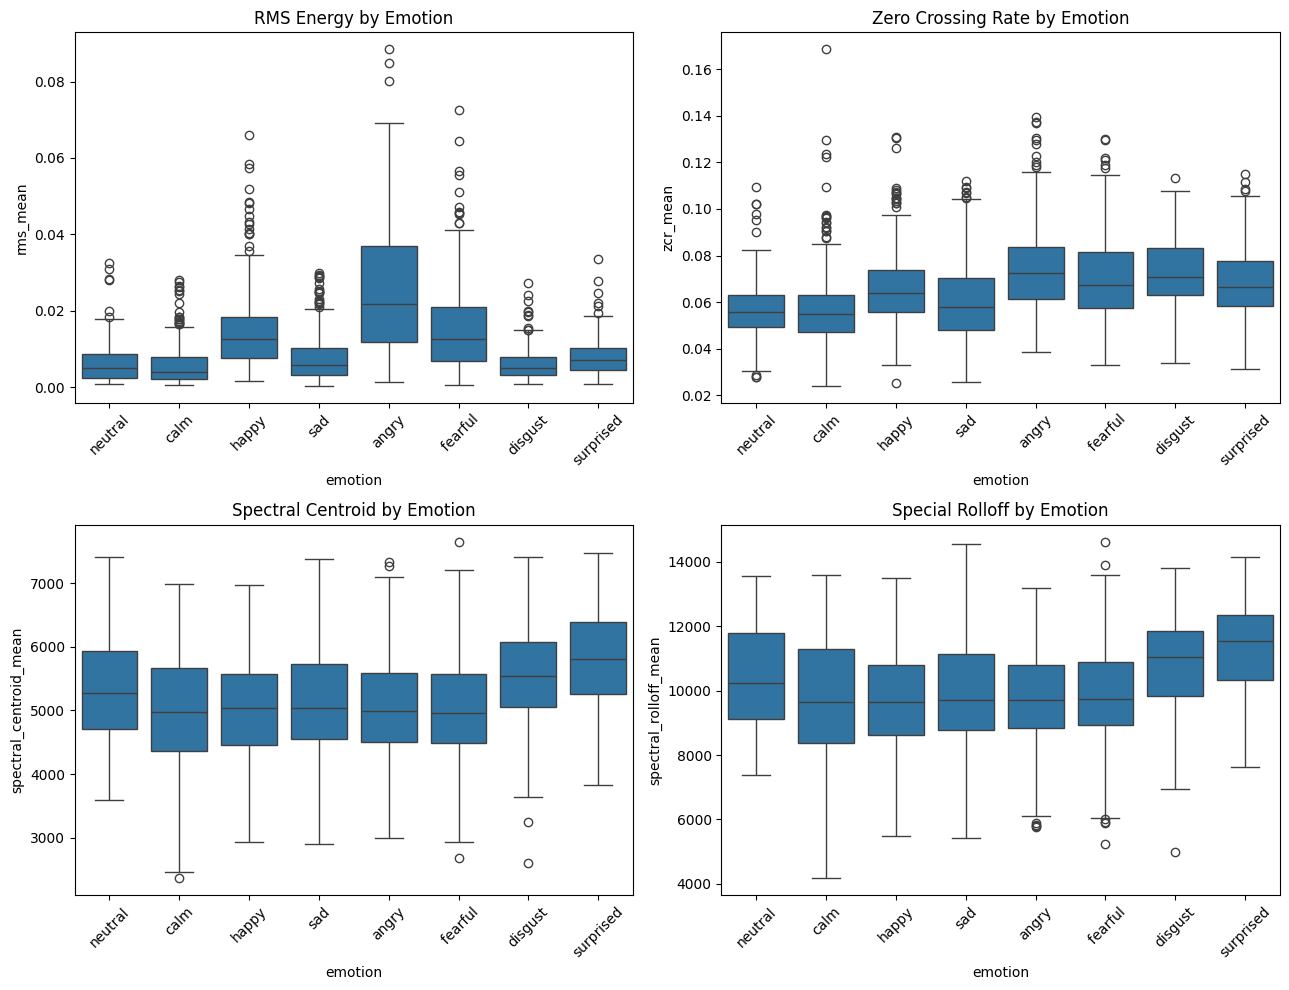

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13,10))

sns.boxplot(data=features_df, x='emotion', y = 'rms_mean', ax=axes[0,0])
axes[0,0].set_title("RMS Energy by Emotion")
axes[0,0].tick_params(axis='x', rotation=45)
sns.boxplot(data=features_df, x='emotion', y='zcr_mean', ax=axes[0,1])
axes[0,1].set_title('Zero Crossing Rate by Emotion')
axes[0,1].tick_params(axis='x', rotation=45)
sns.boxplot(data=features_df, x='emotion', y = 'spectral_centroid_mean', ax= axes[1,0])
axes[1,0].set_title('Spectral Centroid by Emotion')
axes[1,0].tick_params(axis='x', rotation=45)
sns.boxplot(data=features_df, x='emotion', y ='spectral_rolloff_mean', ax=axes[1,1])
axes[1,1].set_title("Special Rolloff by Emotion")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


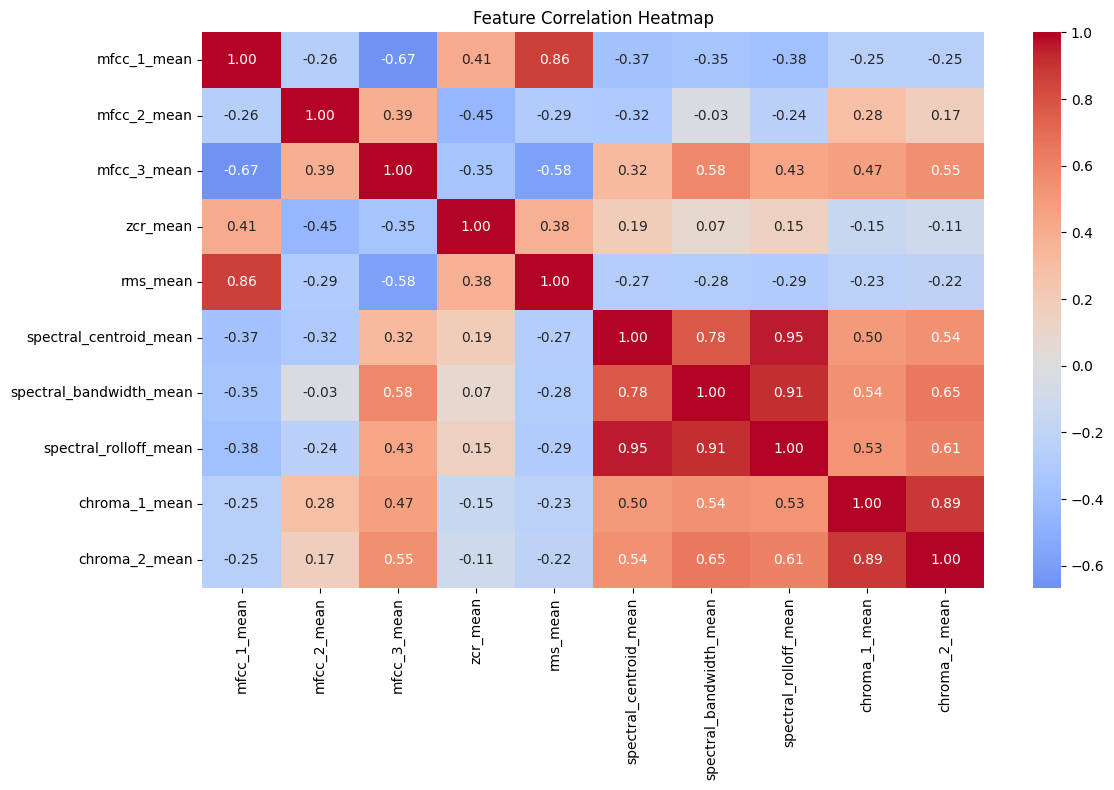

In [9]:
key_features = ['mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean', 'zcr_mean', 'rms_mean', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean', 'chroma_1_mean', 'chroma_2_mean']

plt.figure(figsize=(12,8))
sns.heatmap(features_df[key_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

metadata_cols = ['filename', 'emotion', 'vocal_channel', 'intensity', 'actor', 'gender']
feature_cols = [col for col in features_df.columns if col not in metadata_cols]
from sklearn.model_selection import train_test_split

X = features_df[feature_cols]
y = features_df['emotion']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Set: {X_train_scaled.shape}")
print(f'test Set: {X_test_scaled.shape}')

Training Set: (1961, 112)
test Set: (491, 112)


In [11]:
train_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
train_df['emotion'] = y_train.values
test_df= pd.DataFrame(X_test_scaled, columns=feature_cols)
test_df["emotion"] = y_test.values

train_df.to_csv('../data/train_feature.csv', index=False)
test_df.to_csv('../data/test_deatures.csv', index=False)

print("saved Train and test feature csvs")

saved Train and test feature csvs
